Output()

Output()

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     57.984  0.766  56.384   59.308      0.019    0.013    1716.0    1492.0   
sigma   2.344  0.697   1.310    3.466      0.017    0.013    2012.0    2297.0   

       r_hat  
mu       1.0  
sigma    1.0  


array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>],
      dtype=object)

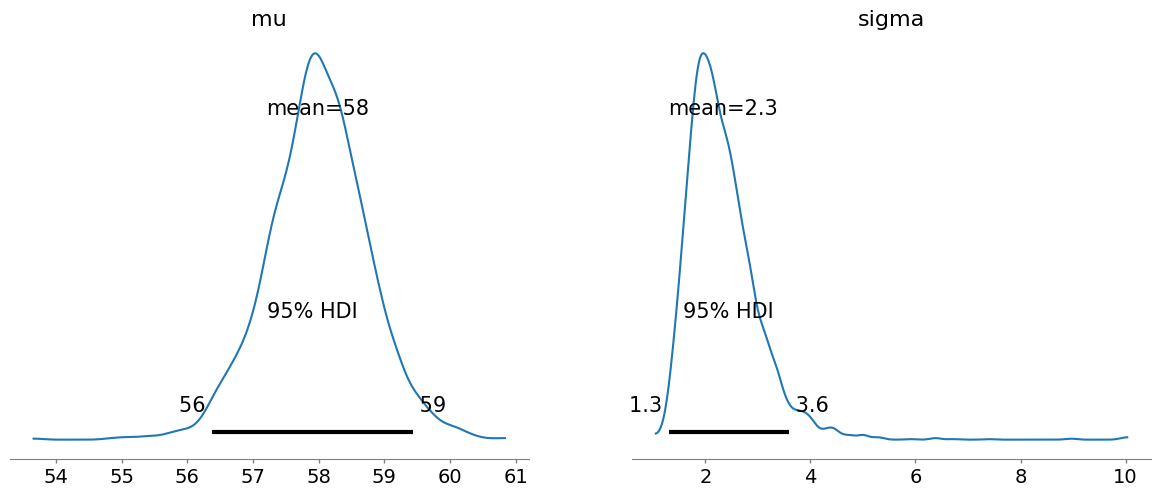

In [3]:
import pymc as pm
import numpy as np
import arviz as az

# Datele observate
data = np.array([56, 60, 58, 55, 57, 59, 61, 56, 58, 60])

# Definirea modelului Bayesian
with pm.Model() as model:

    mu = pm.Normal("mu", mu=np.mean(data), sigma=10) # punctul A
    sigma = pm.HalfNormal("sigma", sigma=10)
    x_obs = pm.Normal("x_obs", mu=mu, sigma=sigma, observed=data)
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, target_accept=0.9) # punctul B (folosim target_accept=0.9 pt a rezolva divergentele)
    #target_accept controleaza rata de acceptare in algoritmul NUTS

print(az.summary(trace, var_names=["mu", "sigma"]))

# Grafic
az.plot_posterior(trace, var_names=["mu", "sigma"], hdi_prob=0.95)



**Reprezentarea valorilor din output**

*   media zgomotului (μ) este estimata ca 57.983.
*   deviatia standard a zgomotului (σ) este estimata ca 2.320.
*   Deviația standard a estimării pentru μ este 0.775
*   Deviația standard a estimării pentru σ este 0.671
*   Pentru μ: intervalul este de la 56.427 la 59.407
*   Pentru σ: intervalul este de la 1.279 la 3.528 -> Exista o probabilitate de 95% ca valorile reale ale lui μ si σ sa se afle in aceste intervale
*   mcse_mean, mcse_sd: Eroarea standard Monte Carlo pt medie si deviatia standard.
*   ess_bulk, ess_tail: Dimensiunea esantionului
*   r_hat: indica o convergenta buna, intrucat varlorile sunt 1.0

**Concluzie:**
 Media estimata este ~58 dB, Deviatia standard - 2.32 dB, Media zgomotului se afla intre ~56 si ~59 dB, Deviatia standard a zgomotului se afla intre ~1.3 si 3.5 dB.

